In [5]:
import pandas as pd

df = pd.read_csv('cluster_4.csv')
y = df['Bankrupt?']
X = df.drop(columns=['Bankrupt?'])

In [6]:
print(X.columns)

Index(['Index', 'ROA(C) before interest and depreciation before interest',
       'ROA(A) before interest and % after tax',
       'ROA(B) before interest and depreciation after tax',
       'Operating Gross Margin', 'Realized Sales Gross Margin',
       'Operating Profit Rate', 'Pre-tax net Interest Rate',
       'After-tax net Interest Rate',
       'Non-industry income and expenditure/revenue',
       'Continuous interest rate (after tax)', 'Operating Expense Rate',
       'Research and development expense rate', 'Cash flow rate',
       'Interest-bearing debt interest rate', 'Tax rate (A)',
       'Net Value Per Share (B)', 'Net Value Per Share (A)',
       'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons',
       'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)',
       'Operating Profit Per Share (Yuan ¥)',
       'Per Share Net profit before tax (Yuan ¥)',
       'Realized Sales Gross Profit Growth Rate',
       'Operating Profit Growth Rate', 'After-tax Net

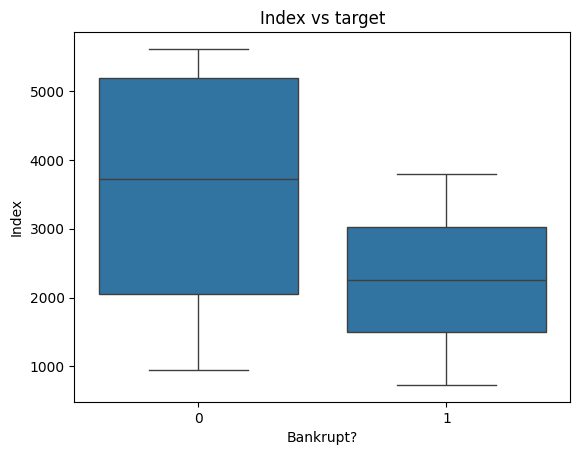

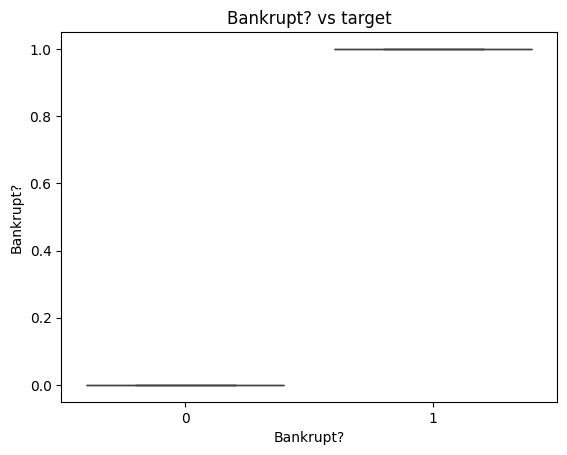

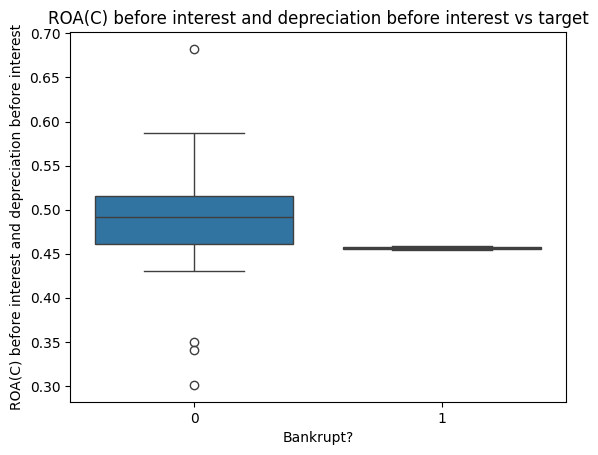

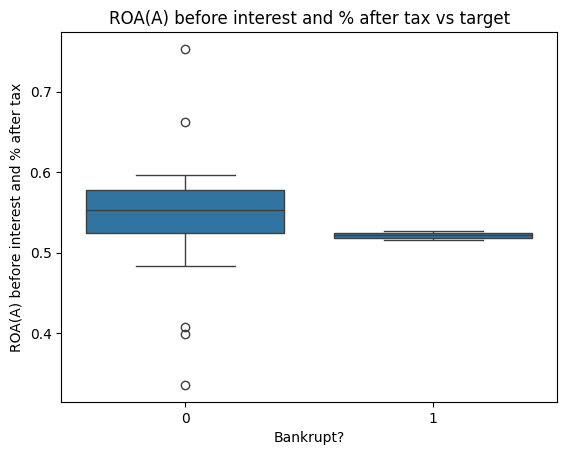

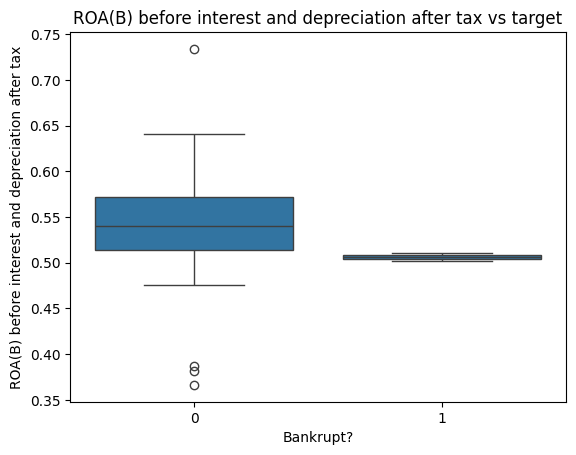

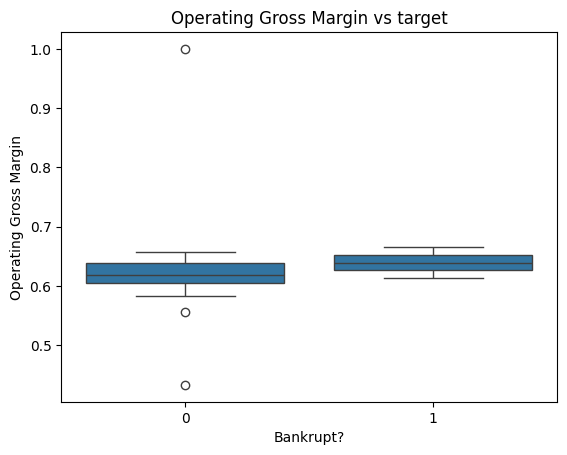

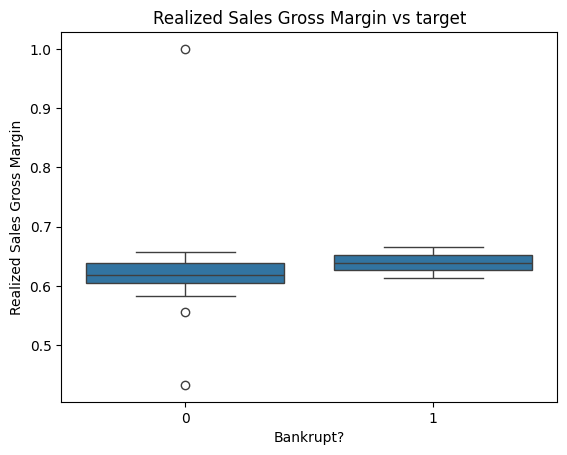

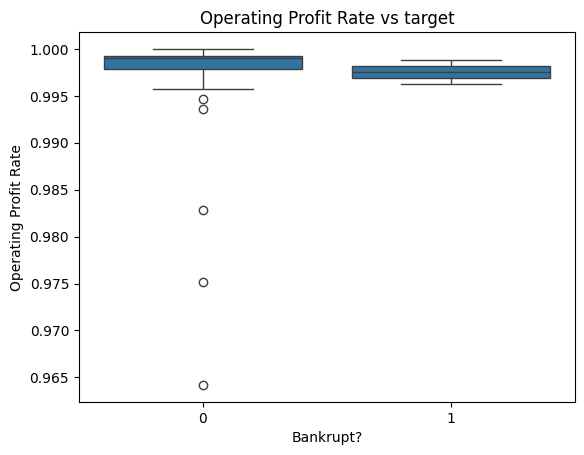

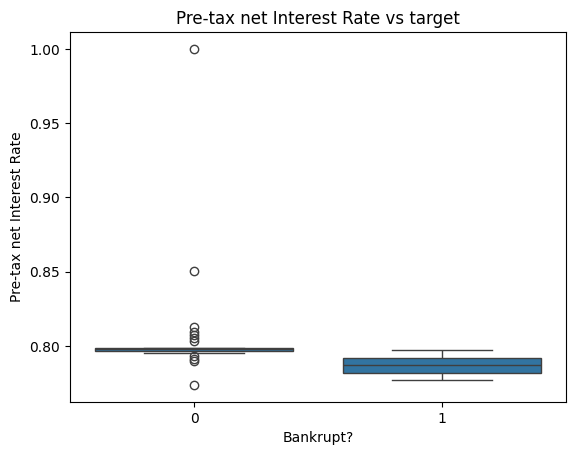

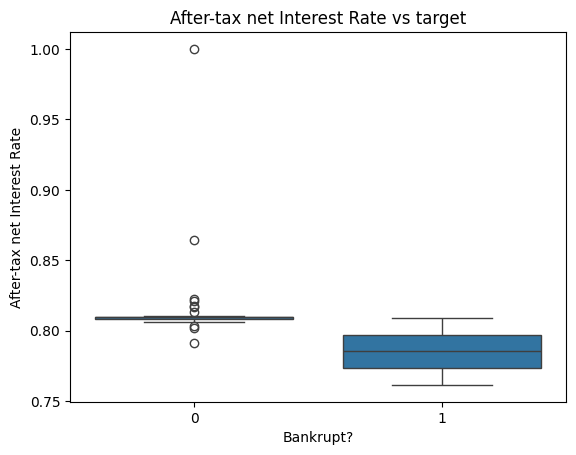

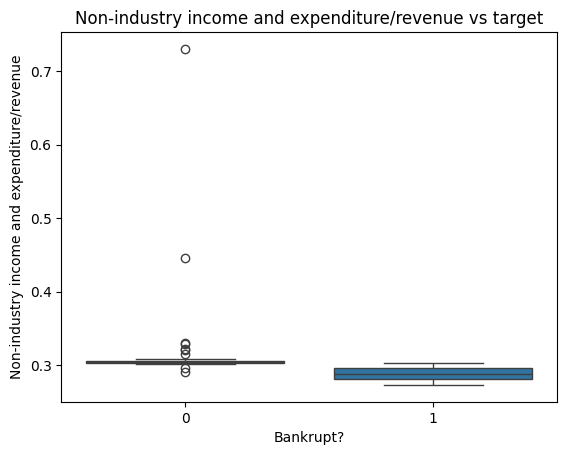

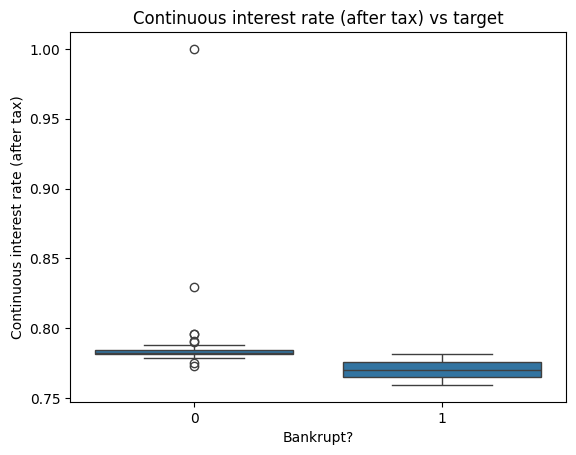

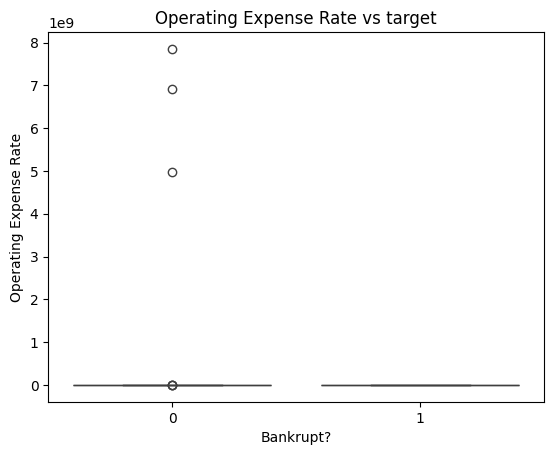

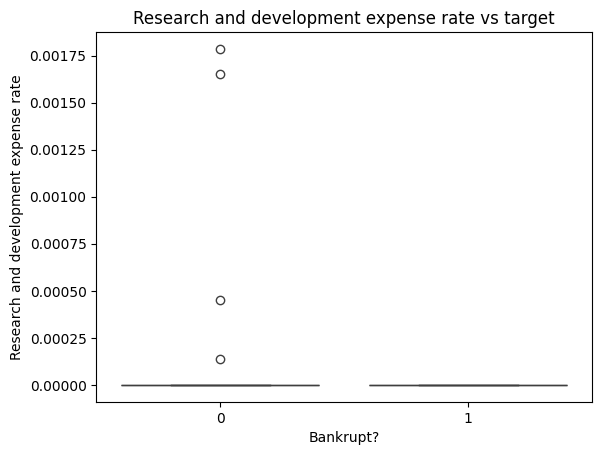

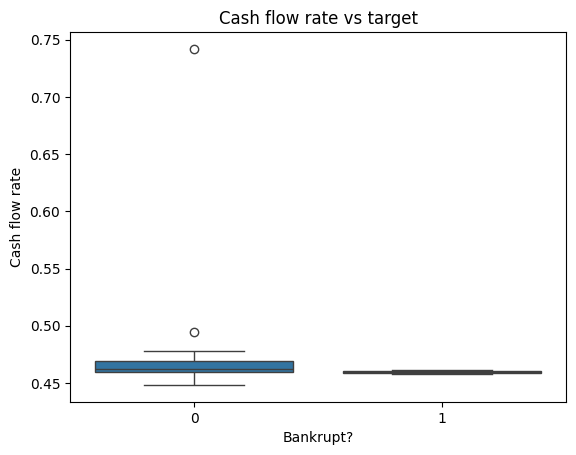

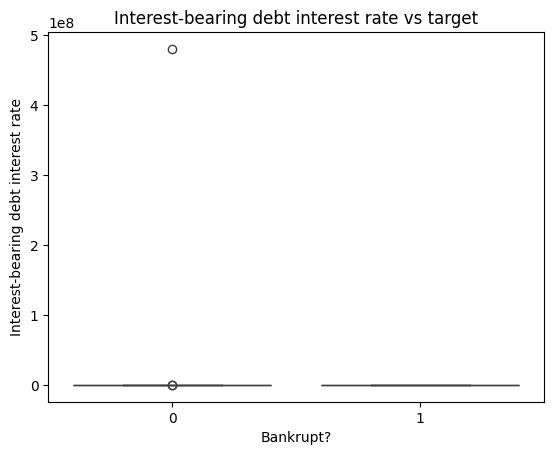

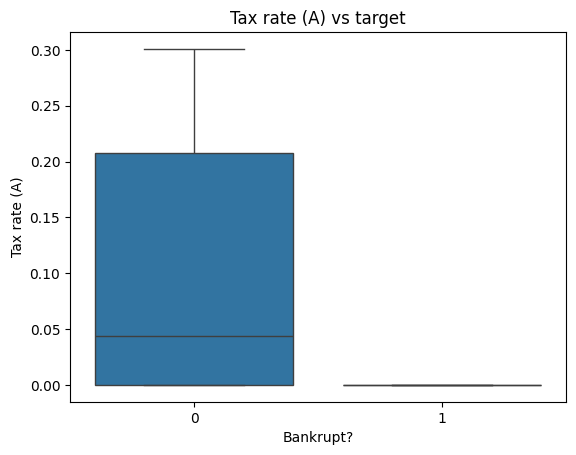

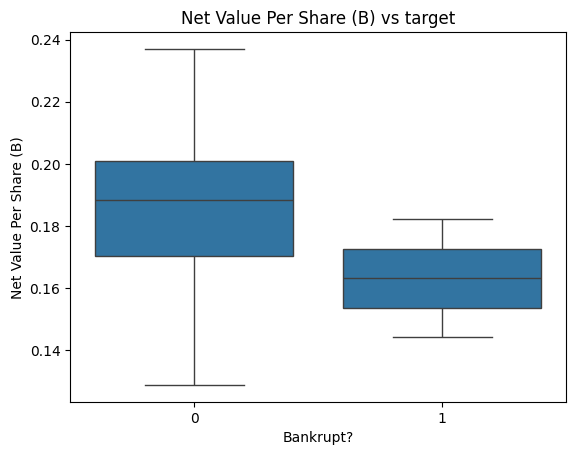

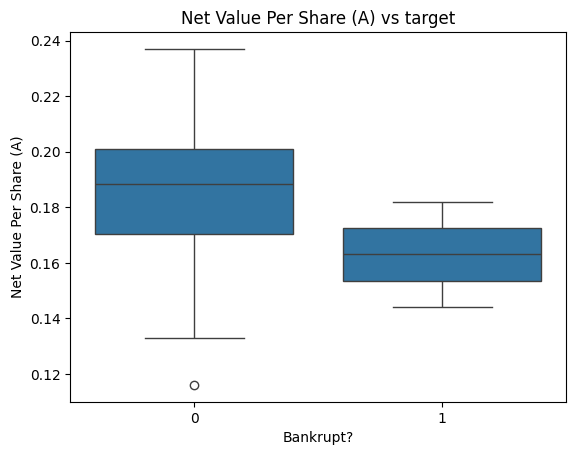

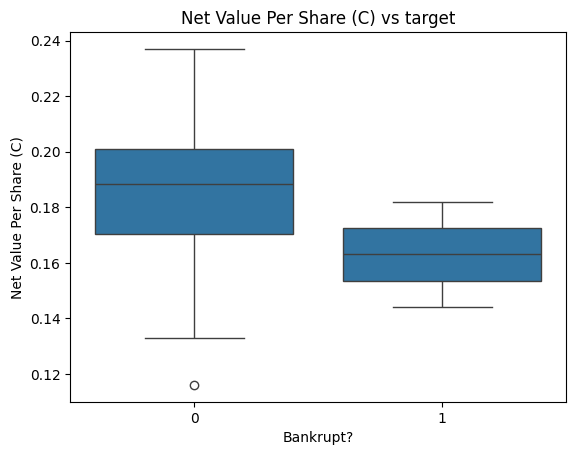

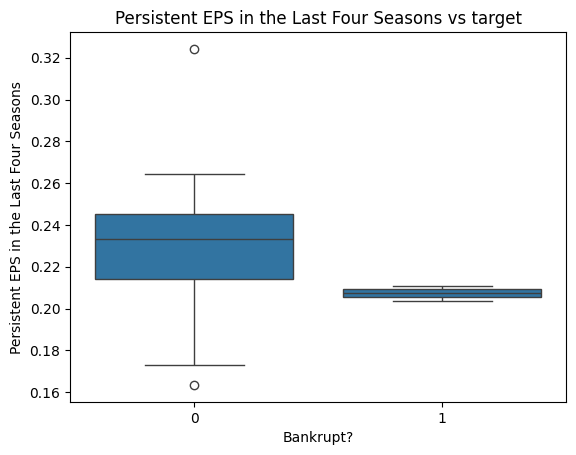

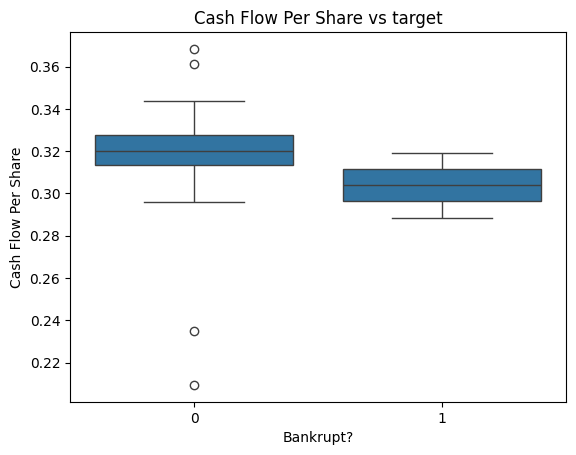

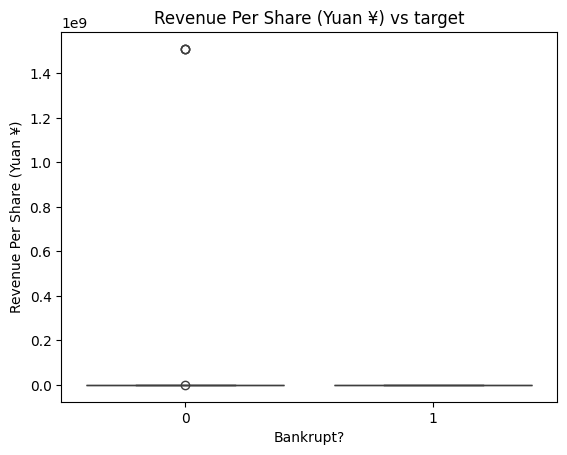

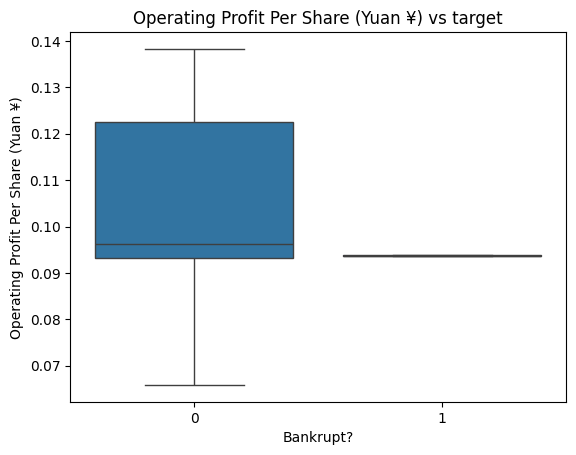

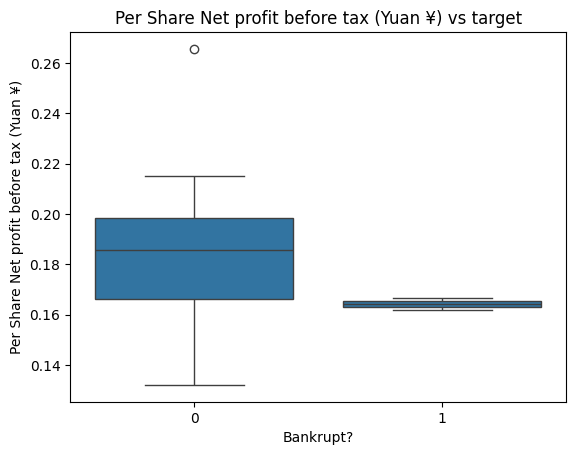

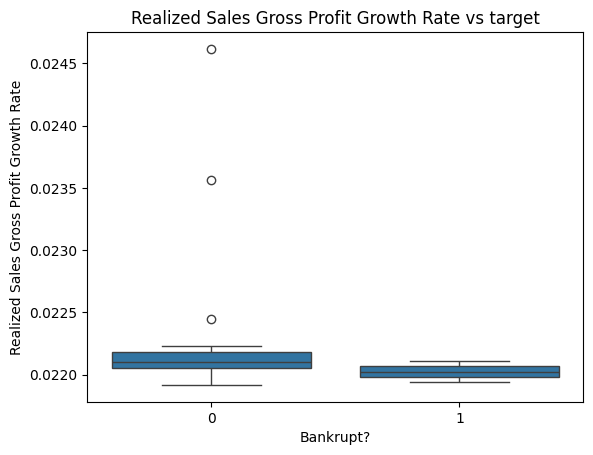

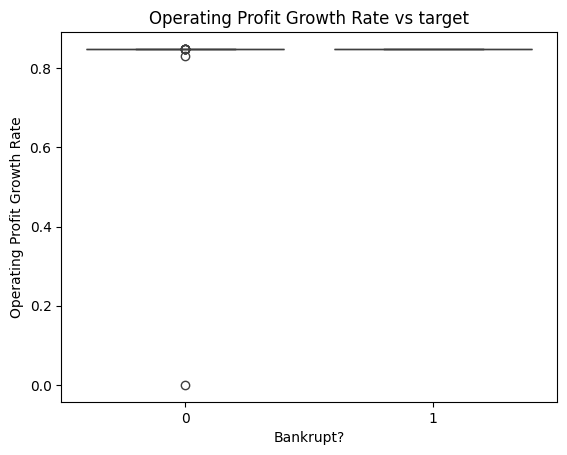

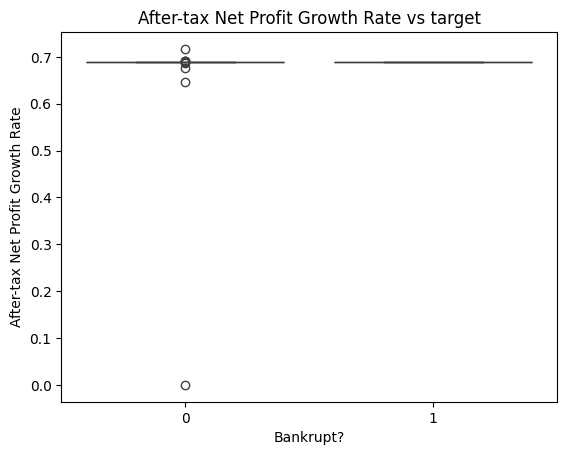

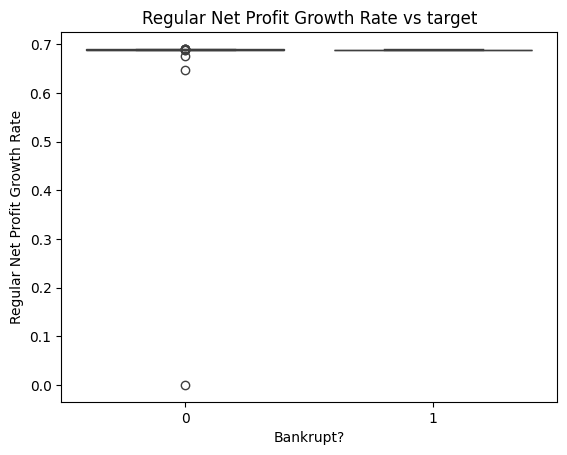

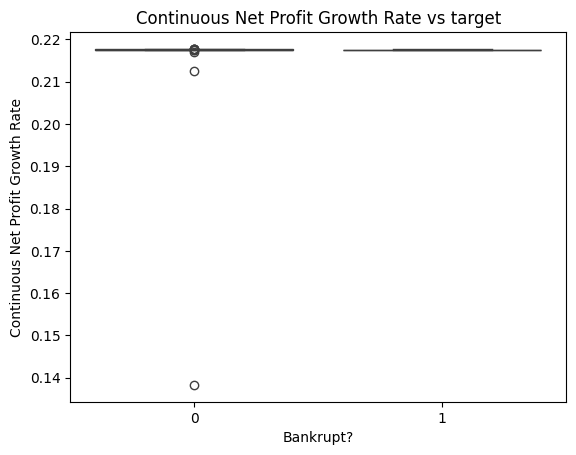

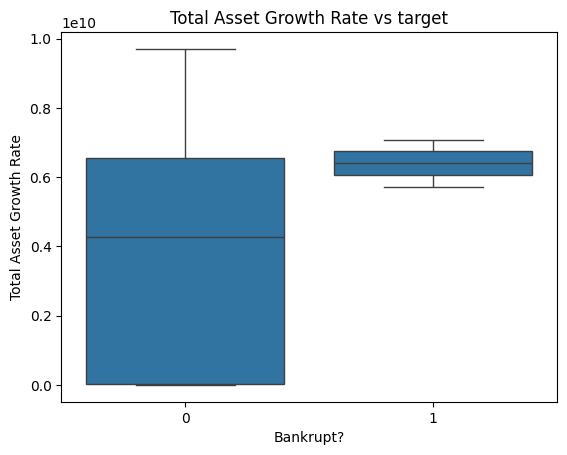

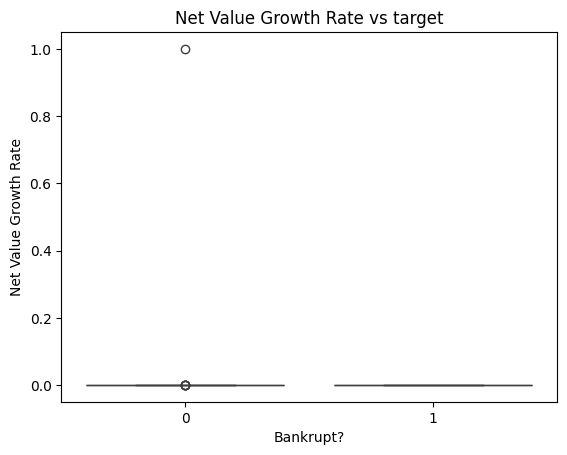

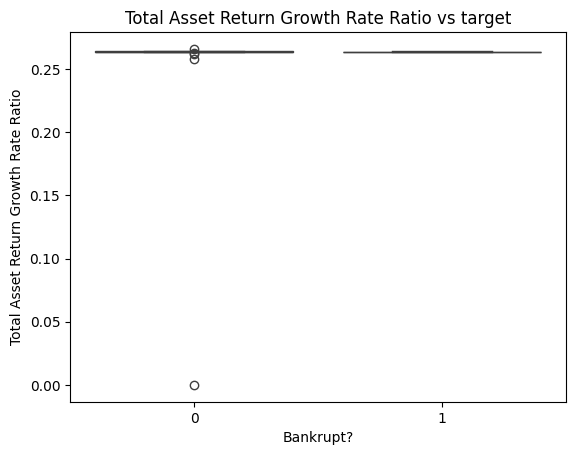

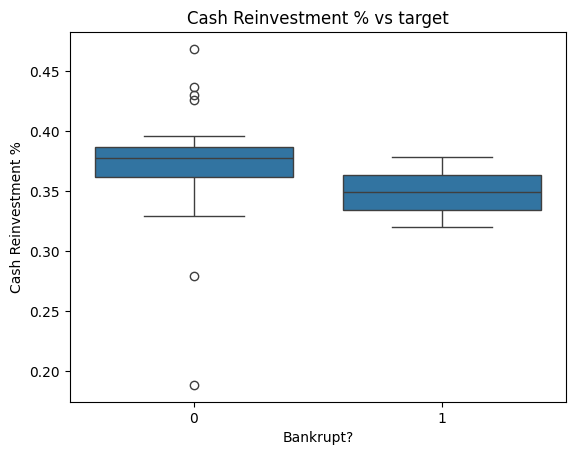

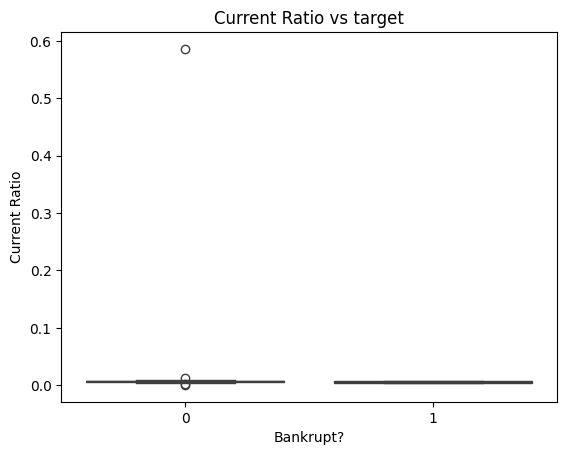

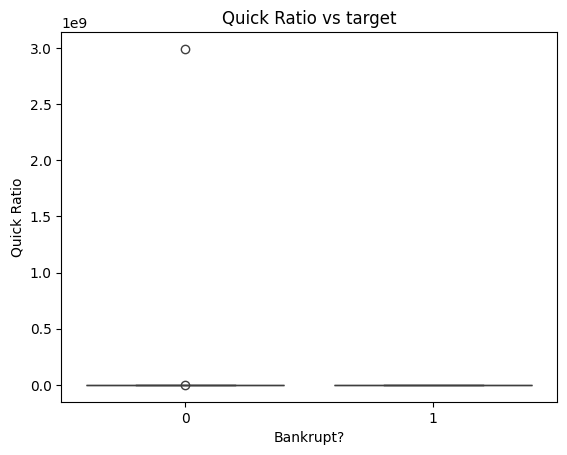

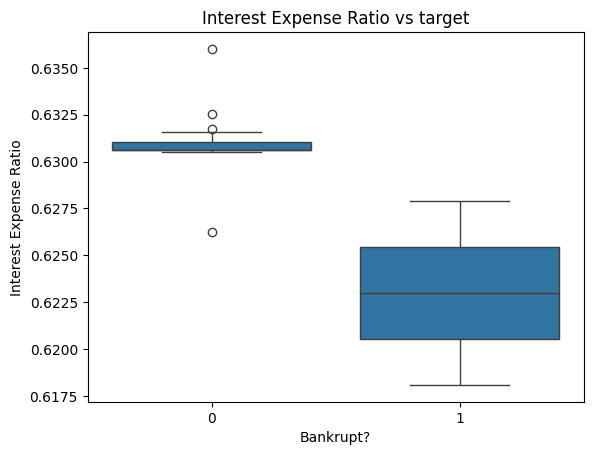

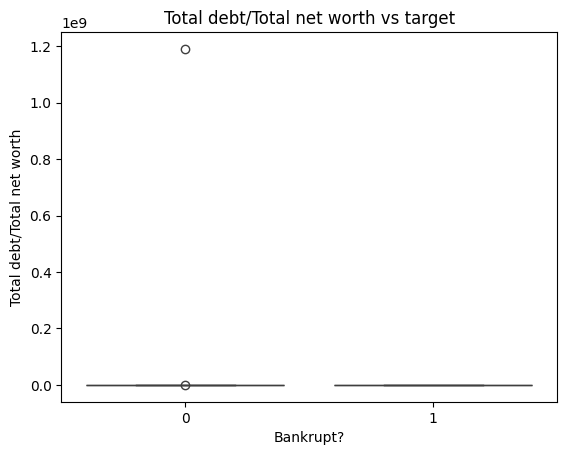

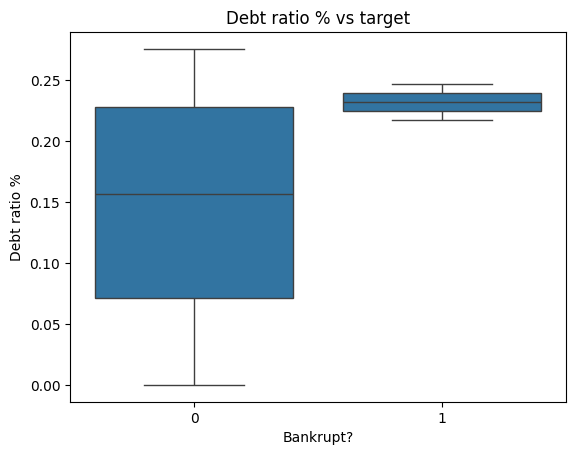

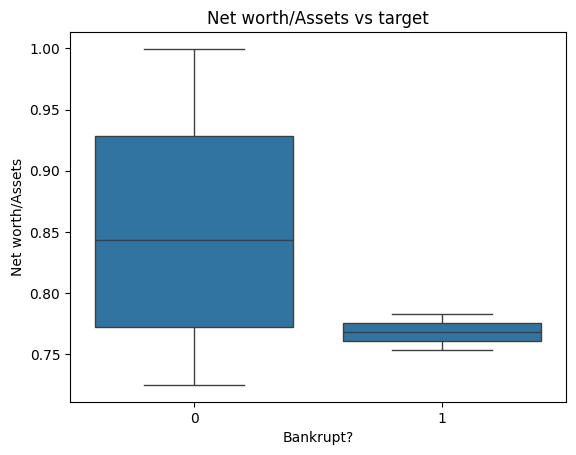

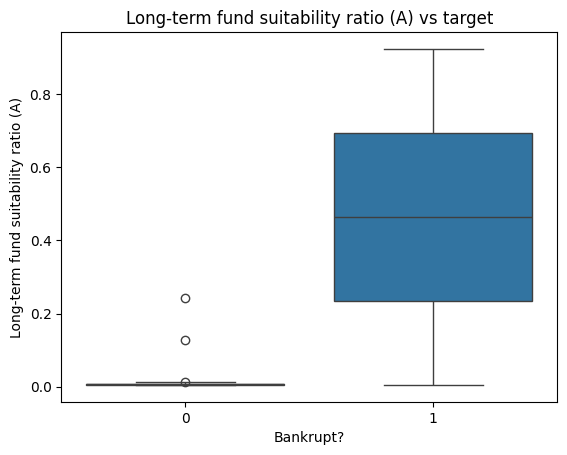

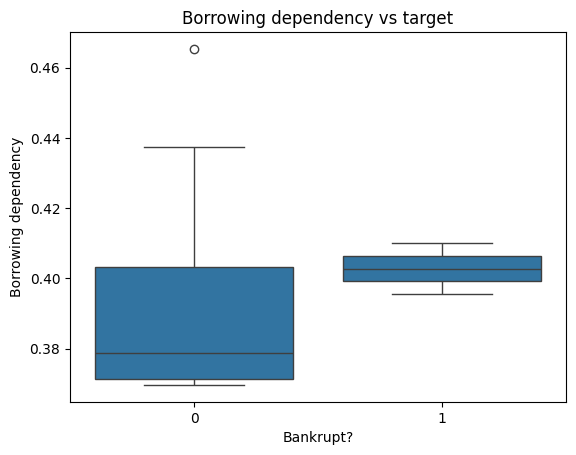

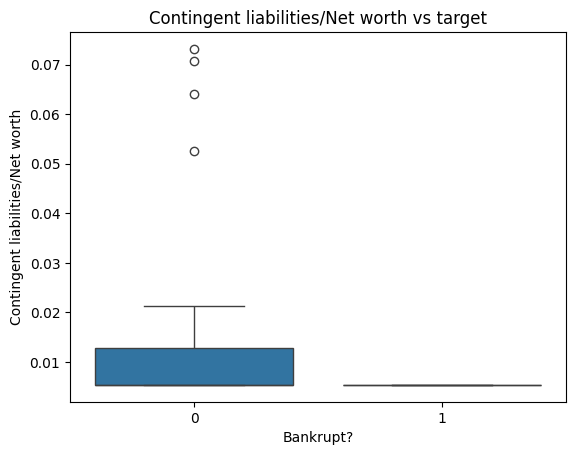

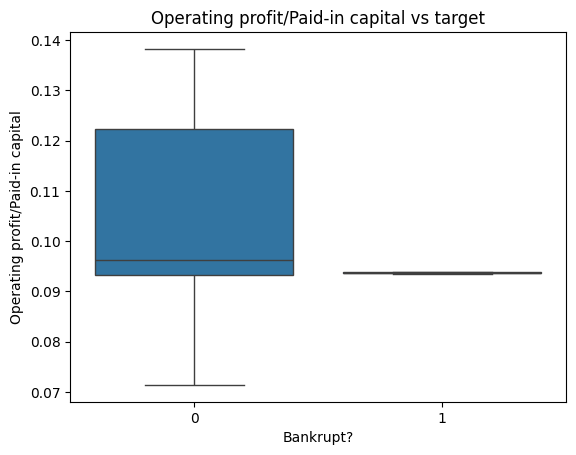

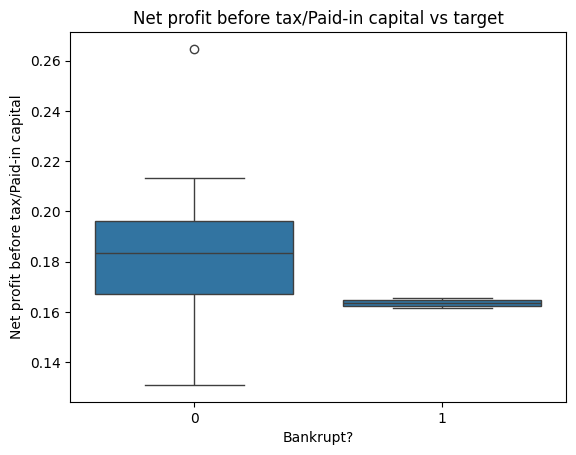

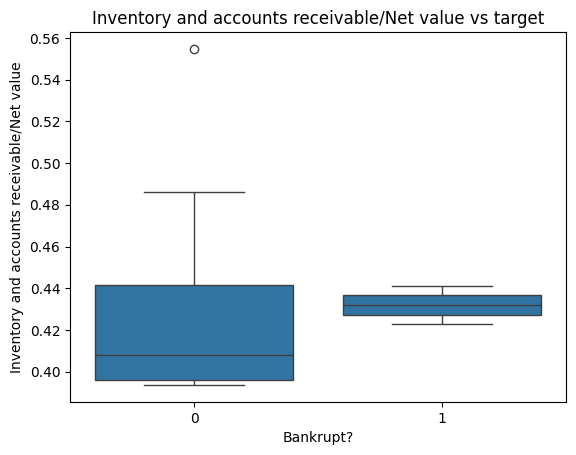

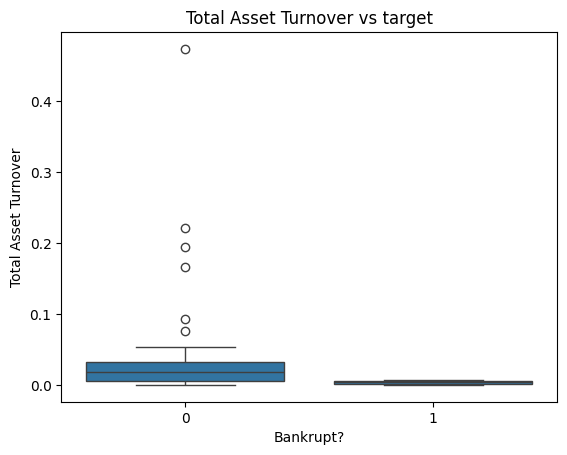

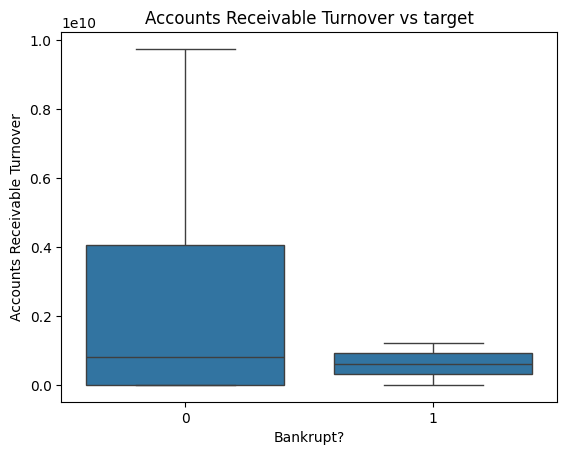

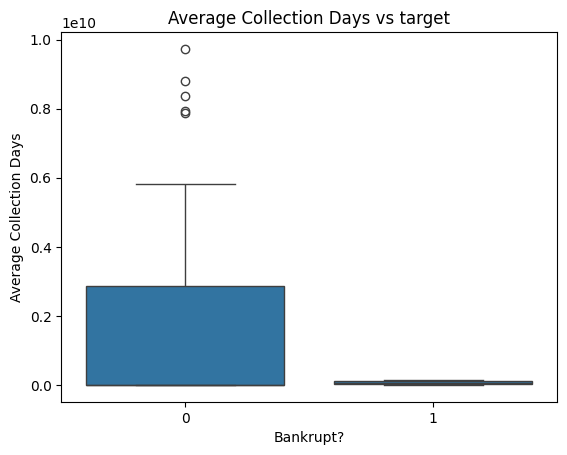

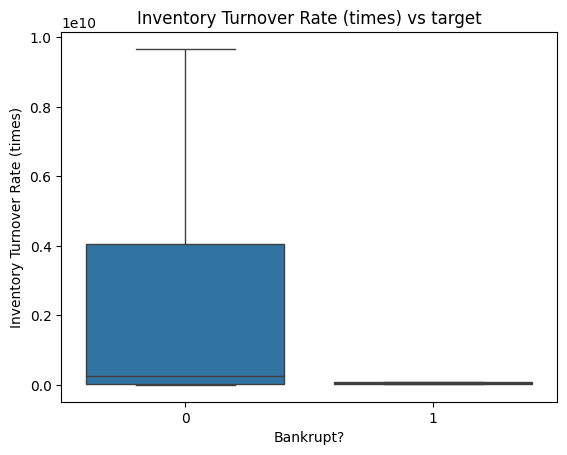

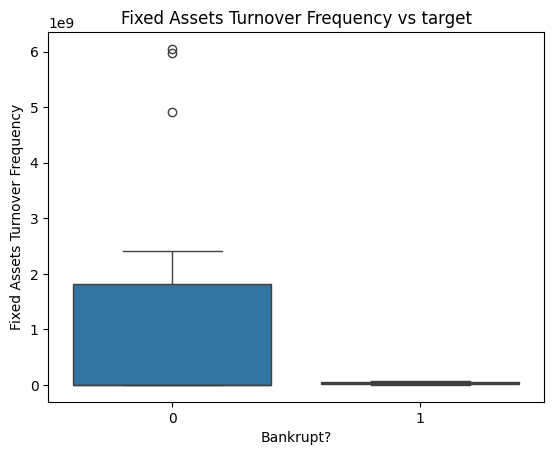

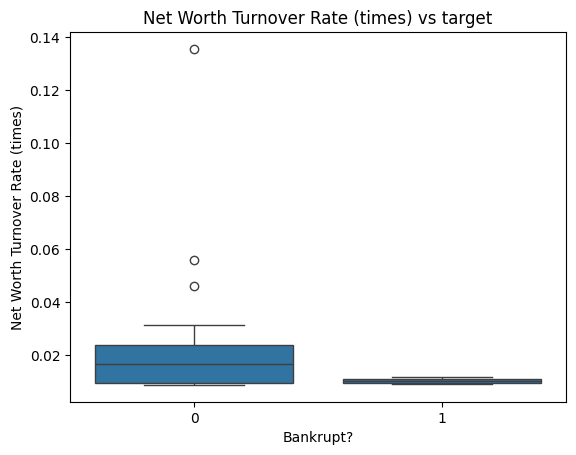

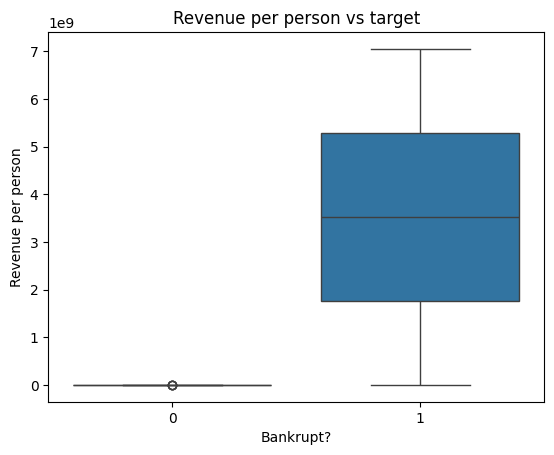

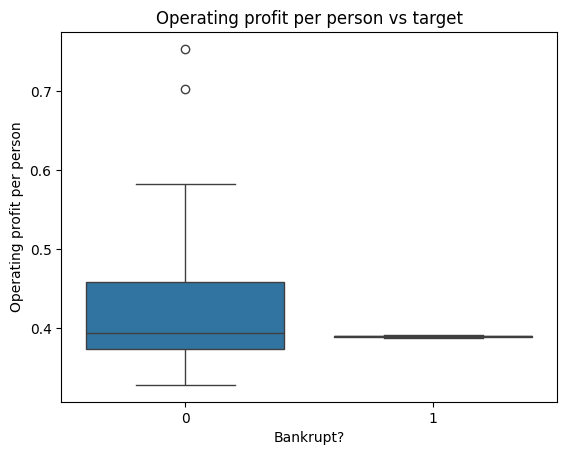

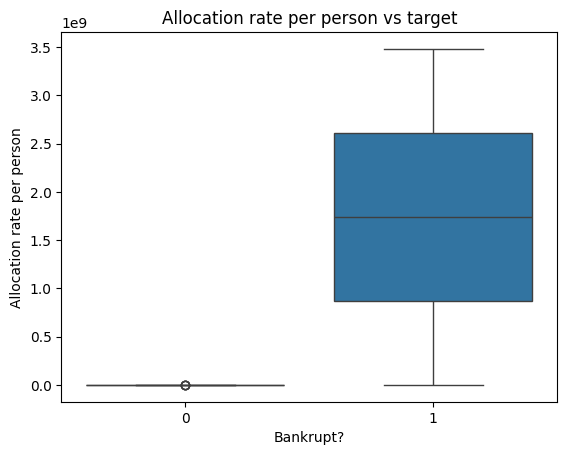

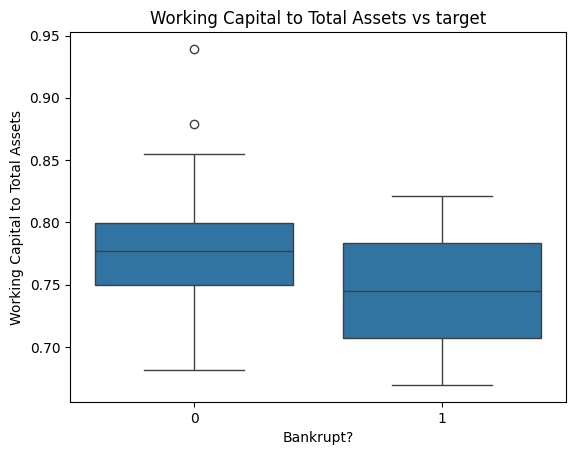

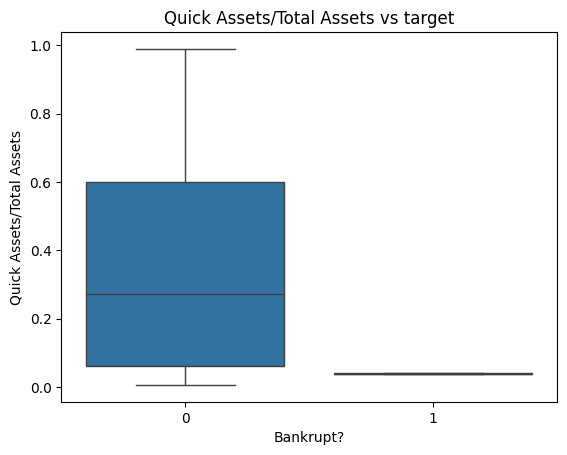

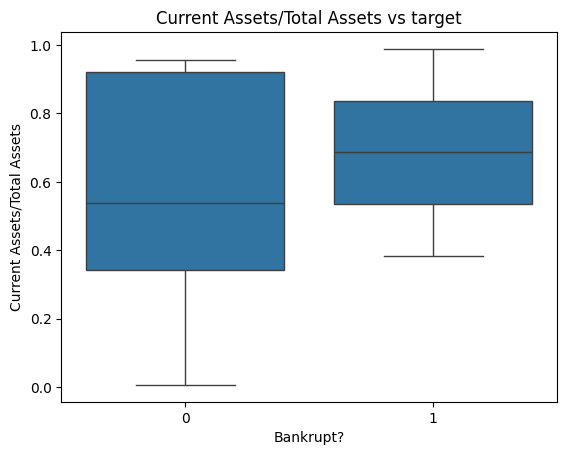

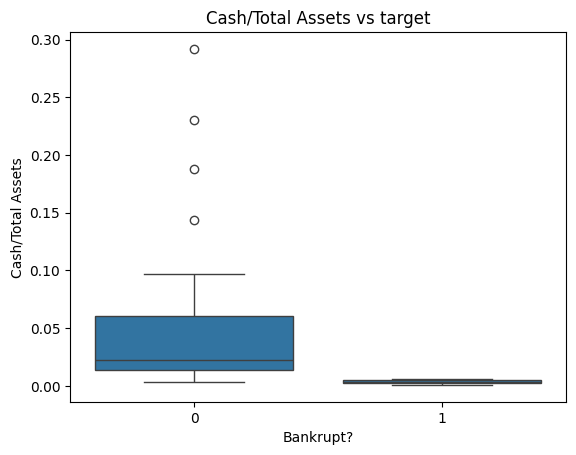

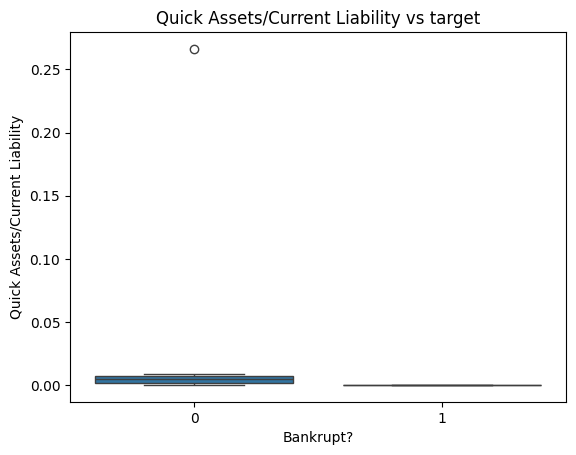

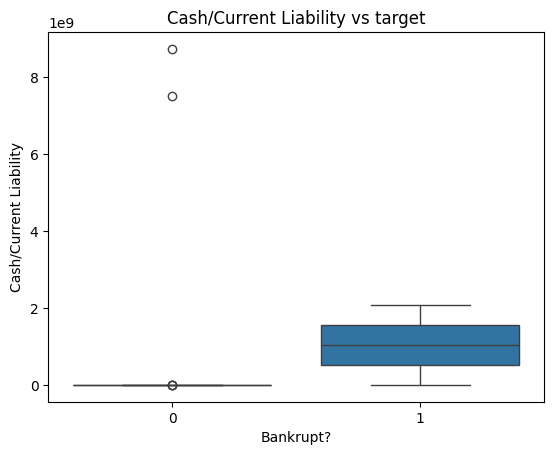

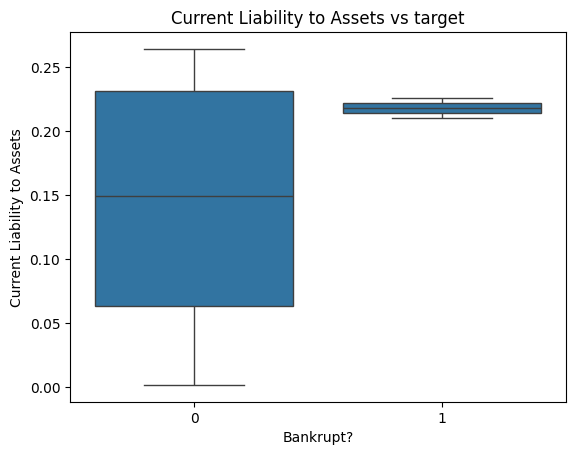

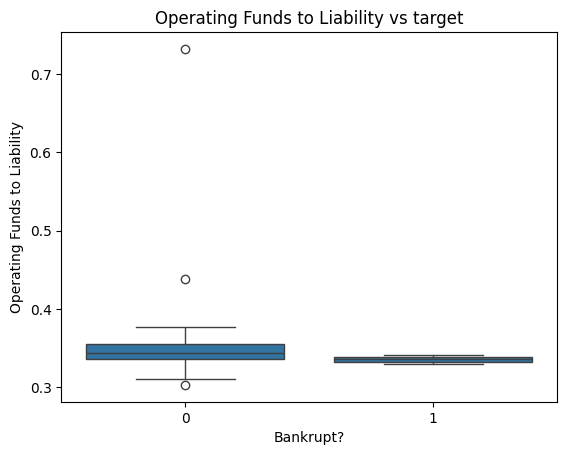

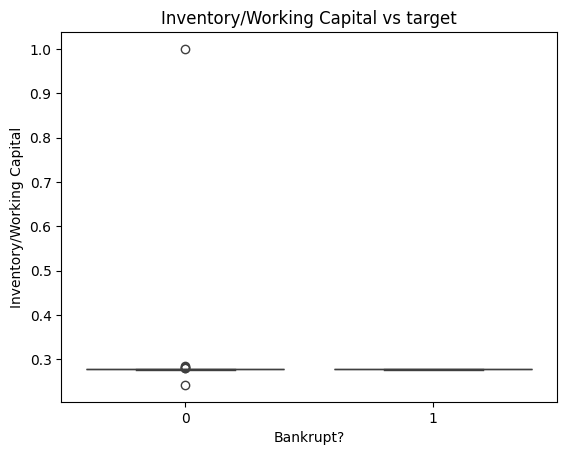

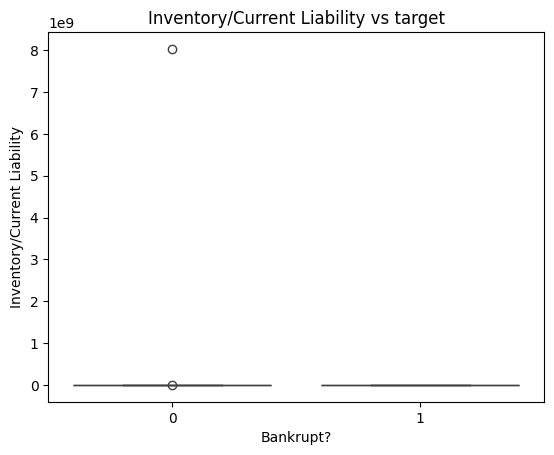

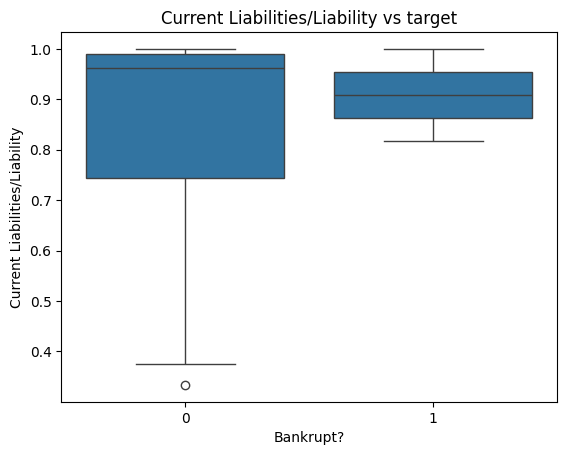

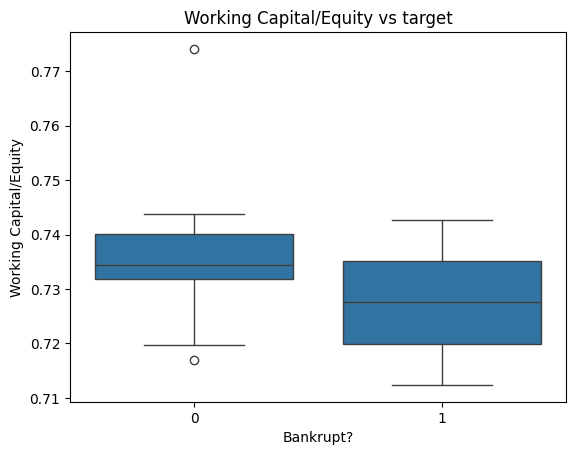

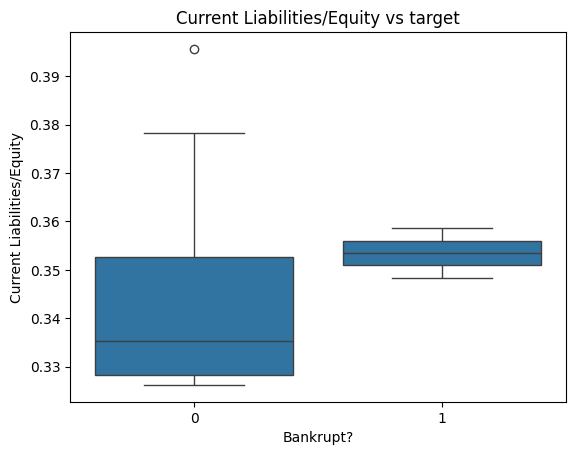

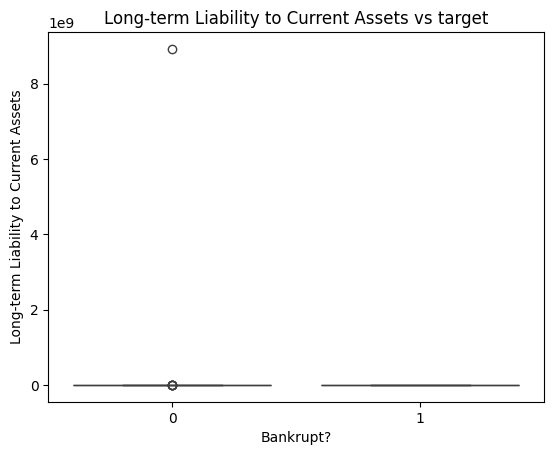

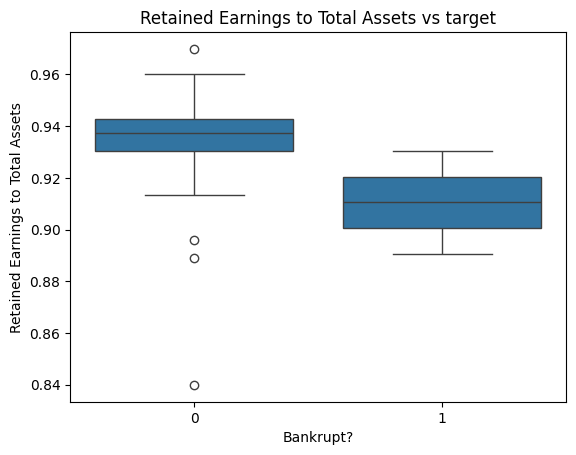

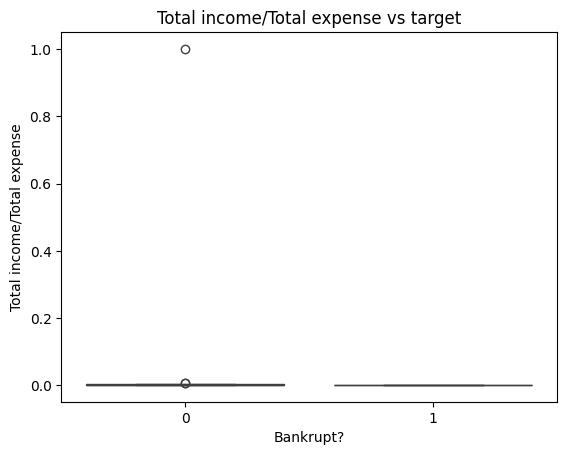

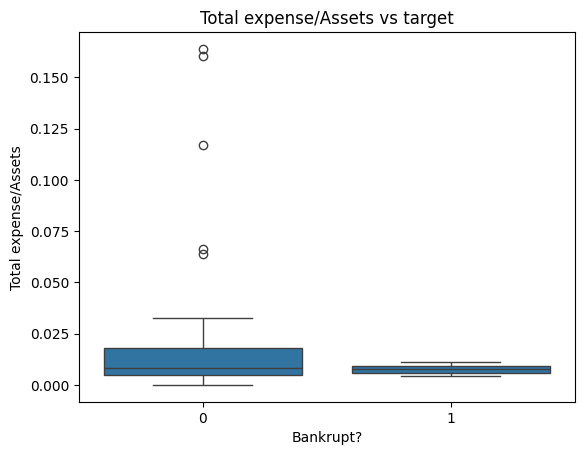

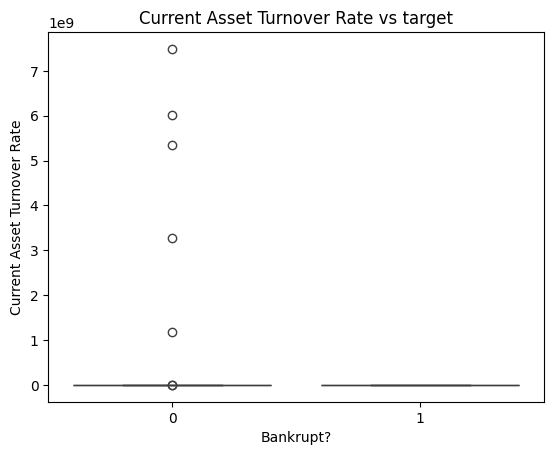

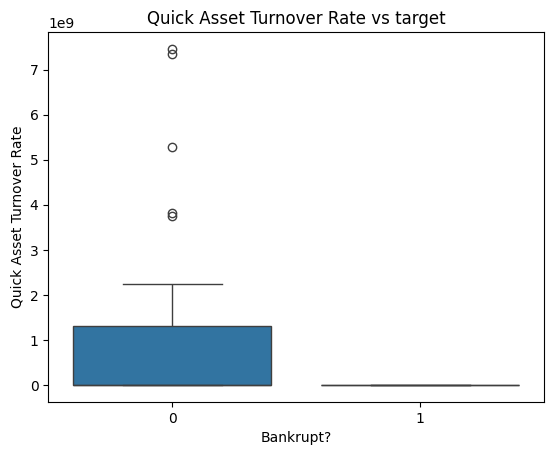

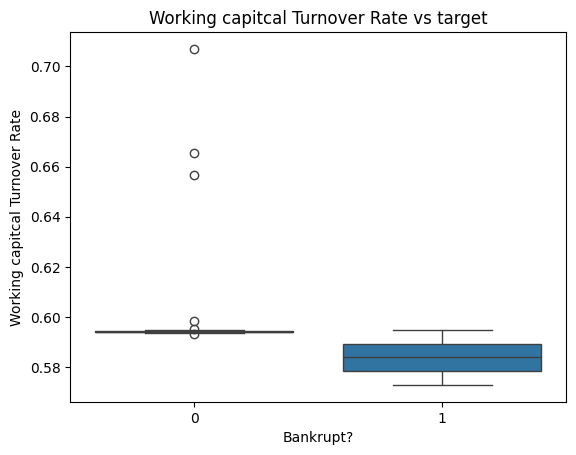

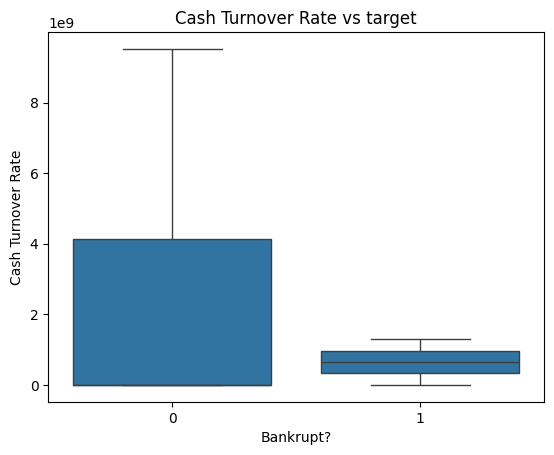

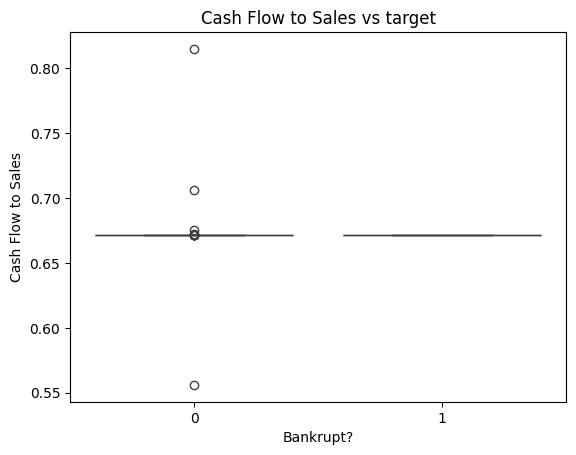

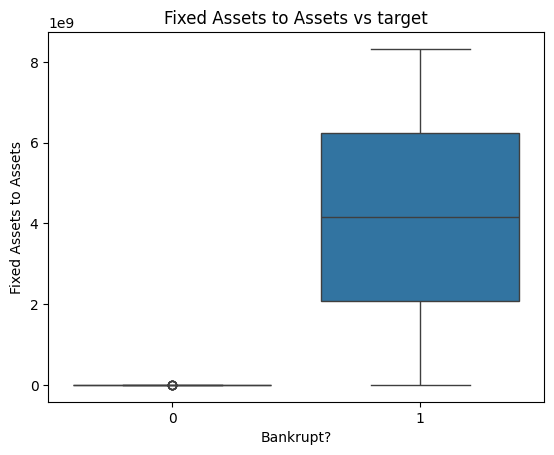

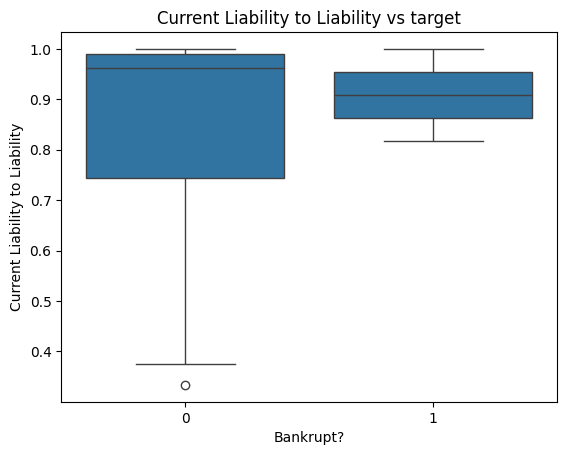

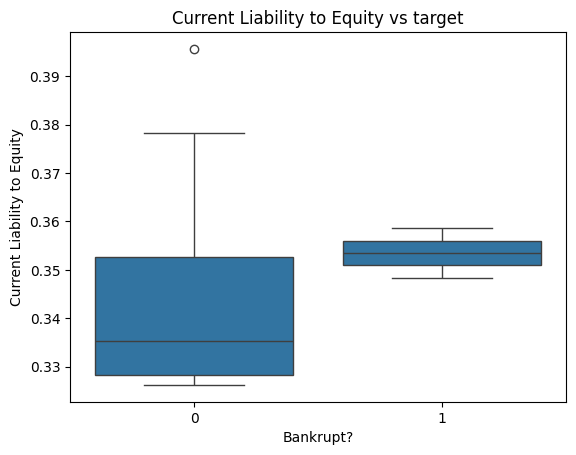

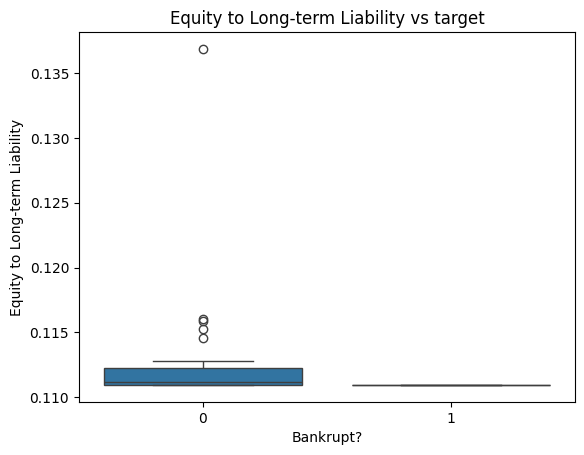

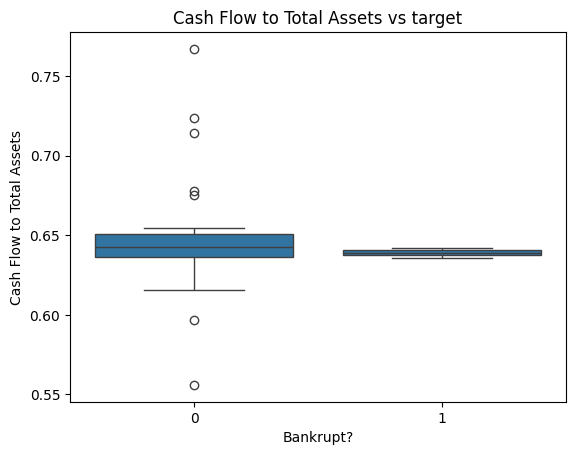

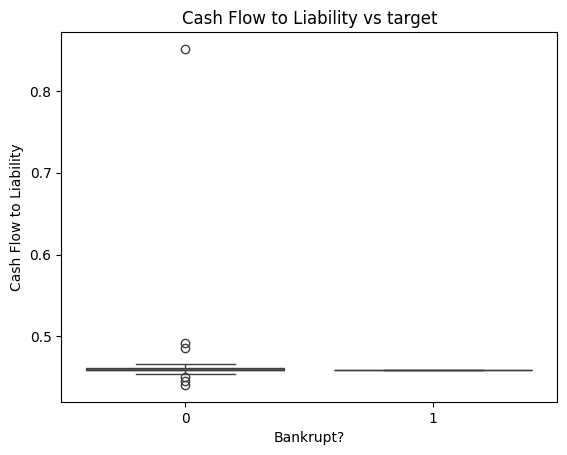

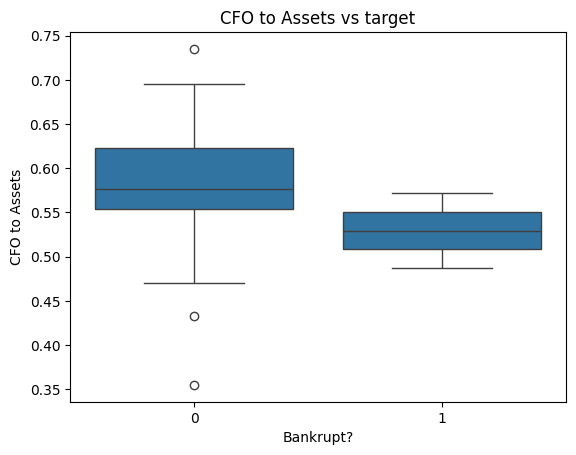

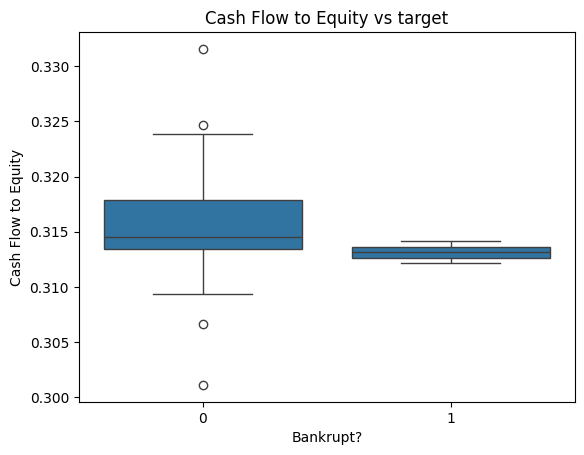

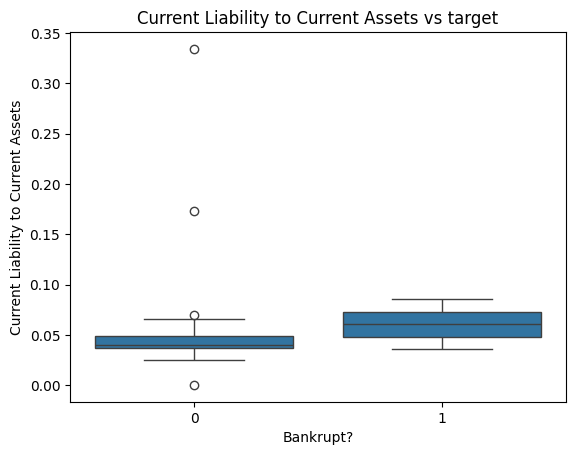

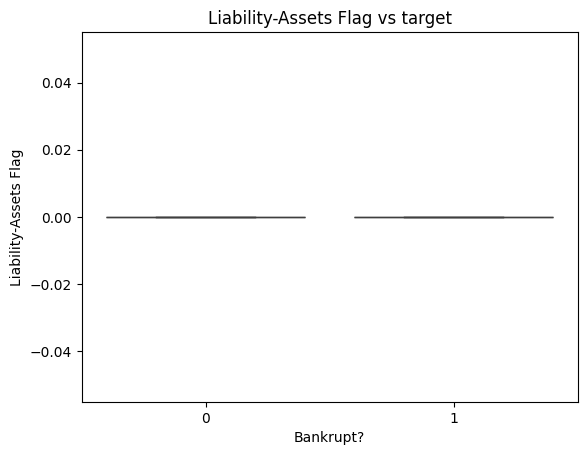

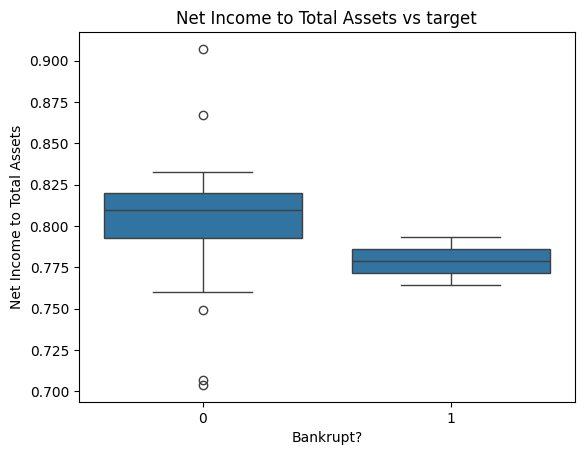

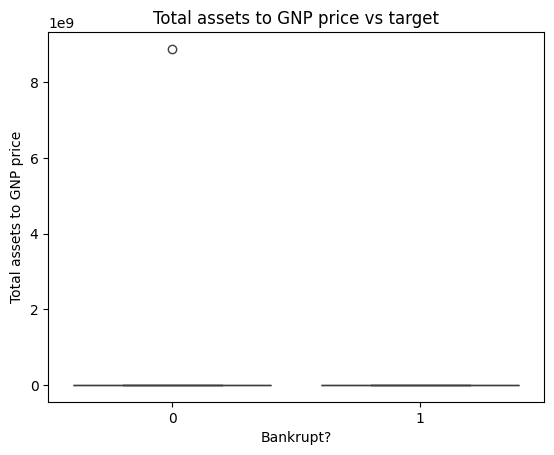

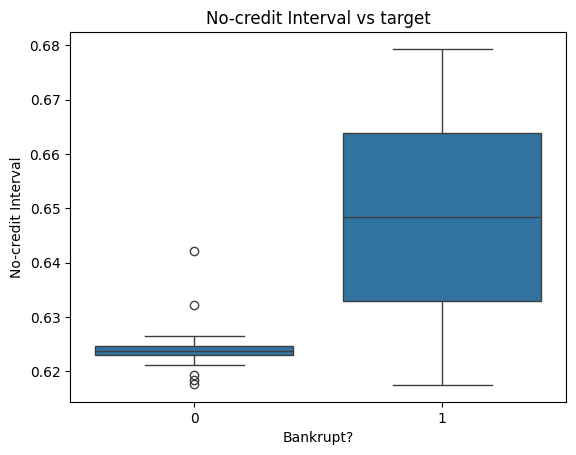

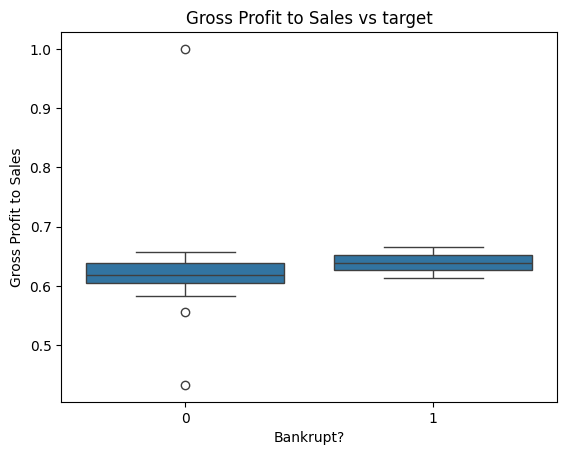

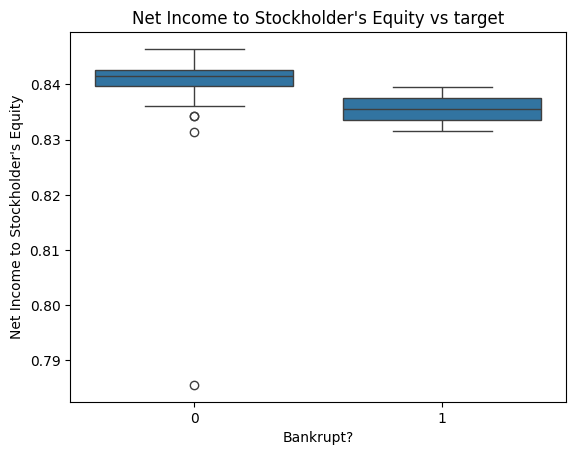

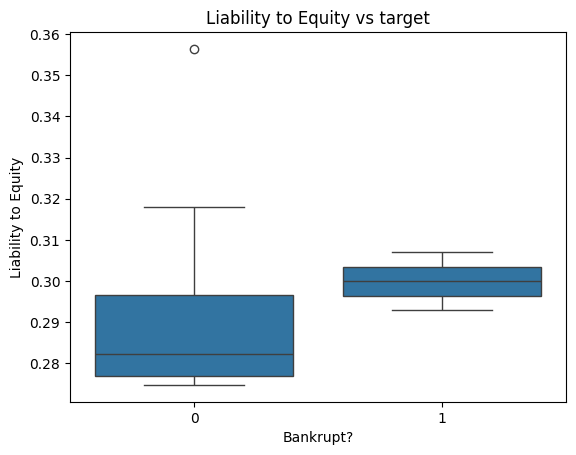

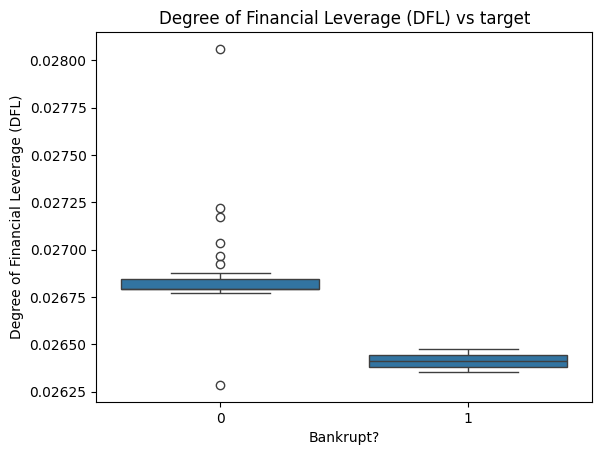

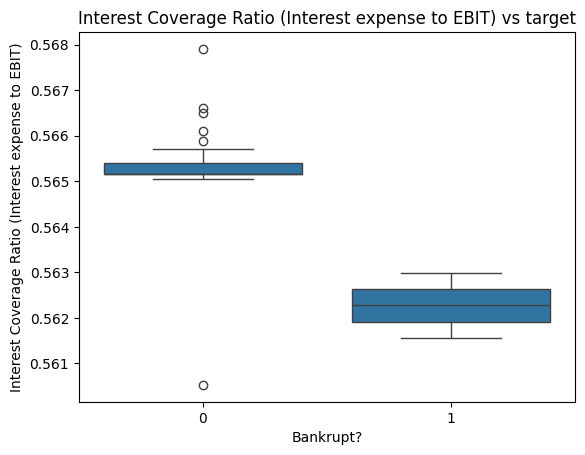

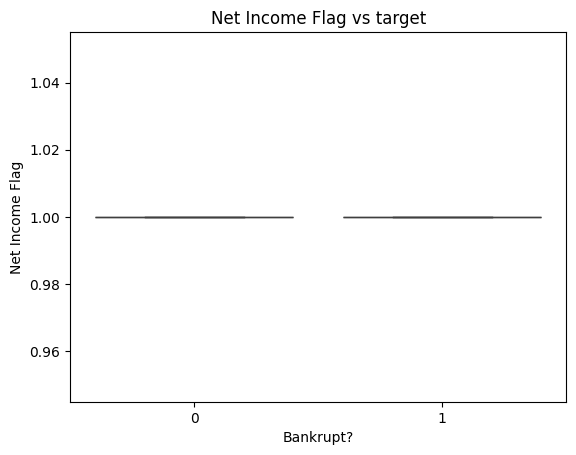

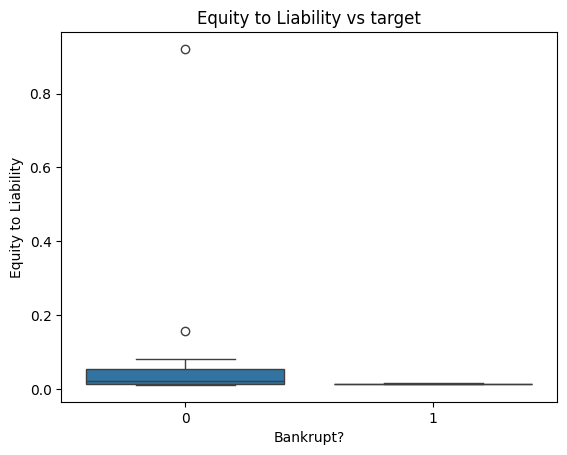

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x=df['Bankrupt?'], y=df[col])
    plt.title(f"{col} vs target")
    plt.show()

The graphs give us a pretty good idea of how each feature is distributed across each of the differnt classes. We see that for some of the features the data is almost completely seperable with the negative class only having a single outlier preventing the data from being seperable. Since the cluster has such a small number of samples and there is really only 1 outlier in some of these graphs for the negative class a relatively accurate model in terms of recall can be made with just only a single feature such as Interest Coverage Ratio (Interest expense to EBIT). The amount of positive samples is also so low that increasing the number of features could lead to overfitting and since having a small numebr of features is important, might as well make it is small as possible.

In [8]:
X2 = df[["Interest Expense Ratio","Interest Coverage Ratio (Interest expense to EBIT)"]]
X2 = df[["Interest Coverage Ratio (Interest expense to EBIT)"]]


## Model Choice Summary

### 1. Stacking Classifier
- **Base learners:**
  - SVM (polynomial kernel, degree=2)
  - K-Nearest Neighbors (k=3)
  - Random Forest (100 trees)
- **Meta-model:** Logistic Regression (balanced class weights)

### 2. SVM

- Captures nonlinear relationships using polynomial kernel
- Class weight handles class imbalance


### 3. K-Nearest Neighbors

- Captures local structure in the feature space
- Useful for identifying small clusters and minority patterns

### 4. Random Forest

- Captures nonlinear interactions between features
- Handles imbalance via class weighting


### 5. Logistic Regression

- Acts as a simple combiner of base model predictions

### 6. SMOTE
- Addresses severe class imbalance in training data
- Generates synthetic minority samples

### 7. StandardScaler

- Required for distance-based models (SVM, KNN)

### 8. ColumnTransformer & CleanColumns
- Removes whitespace and formatting inconsistencies in column names

In [9]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

smote = SMOTE(sampling_strategy=0.8,k_neighbors=1, random_state=42)

base_models = [
    ("svm", SVC(kernel="poly", degree=2, class_weight="balanced", probability=True)),
    ("knn", KNeighborsClassifier(n_neighbors=3, weights="uniform")),
    ("rf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42))
]

stack_model = StackingClassifier(estimators=base_models,final_estimator=LogisticRegression(class_weight="balanced"),cv=2)


class CleanColumns(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, z):
        z = z.copy()
        z.columns = z.columns.str.strip()
        return z

select = ColumnTransformer([("keep", "passthrough", ["Interest Coverage Ratio (Interest expense to EBIT)"])],remainder="drop")

pipe = Pipeline([
    ("clean_cols", CleanColumns()),
    ("select", select),
    ("smote", smote),
    ("scaler", StandardScaler()),
    ("model", stack_model)
])

cv = KFold(n_splits=2, shuffle=True, random_state=42)

scores = cross_val_score(pipe,X2,y,cv=cv,scoring="recall")

print("Recall scores:", scores)


pipe.fit(X2, y)

y_pred = pipe.predict(X)

print("\nPredictions:", y_pred)


/Users/oz/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/oz/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/oz/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/oz/Library/Python/3.9/lib/python/site-packag

Recall scores: [nan  0.]

Predictions: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Recall scores for the cross validation get messed up due to the small number of positive samples in this cluster (only 2) and the splits resulting in either no positive examples at all or a very few number as such the recall scores of nan and 0 aren't really indicative of the model failing. 

In [16]:
import numpy as np



TP = np.sum((y_pred == 1) & (y == 1))

FN = np.sum((y_pred == 0) & (y == 1))

FP = np.sum((y_pred == 1) & (y == 0))
score = TP / (TP + FN) if (TP + FN) != 0 else 0

print("TP:", TP)
print("FN:", FN)
print("FP:", FP)
print("Score:", score)

TP: 2
FN: 0
FP: 1
Score: 1.0


False Negatives and True Positives are the most important as they are directly used in calculating the score. False Negatives are also somewhat important due to their being a limit on the amount allowed, the number here is small enough to not really require worrying about. The model does correctly predict bankruptcy for the two positive cases in this cluster so using the score equation it would receive a 1.0 


In [13]:
import joblib

joblib.dump(pipe, 'cluster_4.joblib')


['cluster_4.joblib']

In [15]:
pipe = joblib.load('cluster_4.joblib')